

2. Gramian Angular Field (GAF)

### 2.1 Concept

The **Gramian Angular Field** represents time series in the **polar coordinate system**, encoding the temporal correlations between each pair of time points as trigonometric relationships.

### 2.2 Mathematical Formulation

Let the original time series be:

$X = [x_1, x_2, \dots, x_n]$

#### Step 1. Normalization

Normalize the values to $[-1, 1]$:

$
\tilde{x}_i = \frac{x_i - \min(X)}{\max(X) - \min(X)} \times 2 - 1
$

#### Step 2. Polar Mapping

Convert each point to polar coordinates:

$
\phi_i = \arccos(\tilde{x}_i), \quad r_i = \frac{i}{n}
$

where $\phi_i$ is the angular component and $r_i$ is the radius proportional to time.

#### Step 3. Construct Gramian Matrix

There are two main variants:

- **GASF (Gramian Angular Summation Field):**
  $
  G_{i,j}^{\text{sum}} = \cos(\phi_i + \phi_j)
  = \tilde{x}_i \tilde{x}_j - \sqrt{1 - \tilde{x}_i^2}\sqrt{1 - \tilde{x}_j^2}
  $

- **GADF (Gramian Angular Difference Field):**
  $
  G_{i,j}^{\text{diff}} = \sin(\phi_i - \phi_j)
  = \tilde{x}_j \sqrt{1 - \tilde{x}_i^2} - \tilde{x}_i \sqrt{1 - \tilde{x}_j^2}
  $

The resulting $n \times n $ matrix can be visualized as an image, where pixel intensity encodes the angular correlation between time points $i$ and $j$.

### 2.3 Interpretation

- Diagonal elements $i=j$ represent the **self-correlation** of each time point.  
- Off-diagonal elements describe the **pairwise temporal relationships**.  
- GAF is sensitive to **trend and phase information** in the sequence.

---

## 3. Markov Transition Field (MTF)

### 3.1 Concept

The **Markov Transition Field** models the **probabilistic dynamics** of time series by encoding the transition probabilities between quantized states over time.

### 3.2 Mathematical Formulation

Let $ X = [x_1, x_2, \dots, x_n]$ be the original series.

#### Step 1. Discretization

Discretize the continuous series into Q  quantile-based states:

$
S = [s_1, s_2, \dots, s_n], \quad s_i \in \{1, 2, \dots, Q\}
$

#### Step 2. Transition Probability Matrix

Compute the first-order **Markov transition matrix**  P :

$
P_{i,j} = P(s_{t+1} = j \mid s_t = i)
$

#### Step 3. Construct the Markov Transition Field

For each pair of time indices $ (p, q) $:

$
MTF_{p,q} = P_{s_p, s_q}
$

This produces an $n \times n $ image where each pixel value corresponds to the transition probability between the states at time p and q.

### 3.3 Interpretation

- The diagonal reflects **self-transition** probabilities (stability).  
- Off-diagonal elements capture the **temporal co-occurrence** of state transitions.  
- MTF emphasizes the **dynamic behavior** of the system.

---

## 4. Comparison of GAF and MTF

| Feature | GAF (Gramian Angular Field) | MTF (Markov Transition Field) |
|----------|-----------------------------|-------------------------------|
| **Idea** | Polar coordinate + trigonometric correlation | Markov state transition probabilities |
| **Input Type** | Continuous time series | Discretized time series |
| **Output Matrix** | Angular correlation matrix | Transition probability matrix |
| **Captures** | Global phase and trend | Temporal dynamics and transition structure |
| **Diagonal Meaning** | Self-correlation | Self-transition probability |
| **Applications** | ECG/EEG, gesture recognition | Dynamic pattern recognition, behavior modeling |

---



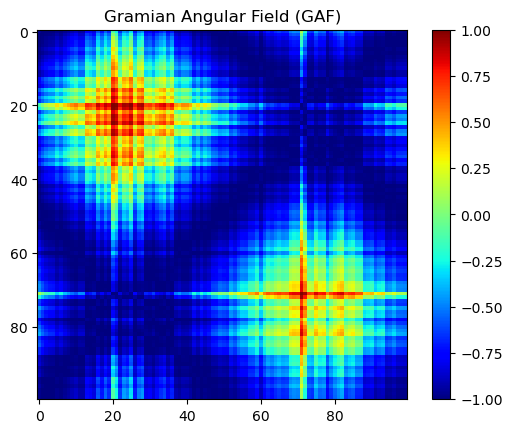

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


t = np.linspace(0, 2*np.pi, 100)
x = np.sin(t) + 0.1*np.random.randn(100)

# 归一化到 [-1,1]
x_scaled = (x - np.min(x)) / (np.max(x) - np.min(x)) * 2 - 1
phi = np.arccos(x_scaled)

# 计算 GAF (cosine 版)
GAF = np.cos(phi[:, None] + phi[None, :])

plt.imshow(GAF, cmap='jet')
plt.title("Gramian Angular Field (GAF)")
plt.colorbar()
plt.show()


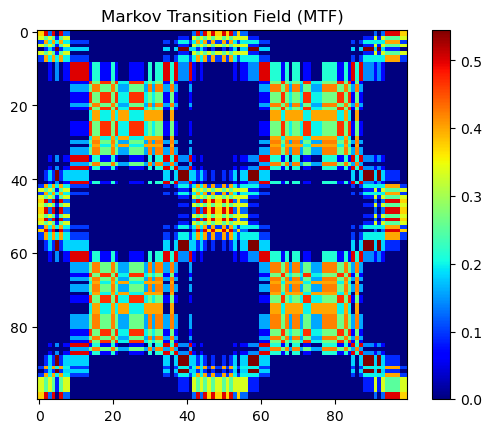

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 示例速度信号
x = np.abs(np.sin(np.linspace(0, 2*np.pi, 100)) + 0.1*np.random.randn(100))

# 1. 离散化到若干状态
num_bins = 8
bins = np.linspace(0, np.max(x), num_bins+1)
states = np.digitize(x, bins) - 1
# 🔧 修正：强制截断到合法范围 [0, num_bins-1]
states = np.clip(states, 0, num_bins-1)

# 2. 统计状态转移概率
P = np.zeros((num_bins, num_bins))
for i in range(len(states)-1):
    P[states[i], states[i+1]] += 1
P = P / (P.sum(axis=1, keepdims=True) + 1e-8)

# 3. 构建 MTF 图
MTF = np.zeros((len(states), len(states)))
for i in range(len(states)):
    for j in range(len(states)):
        MTF[i, j] = P[states[i], states[j]]

plt.imshow(MTF, cmap='jet')
plt.title("Markov Transition Field (MTF)")
plt.colorbar()
plt.show()
